In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges1 as pr
import seaborn as sns
from skimage import filters as sk

In [2]:
k27 = pr.read_bed("seacr_tests/test_output/bedfiles_quantile/CT-SEM_H3K27ac_chr7_9_13.bed")
mll = pr.read_bed("seacr_tests/test_output/bedfiles_quantile/CT-SEM_MLL_chr7_9_13.bed")

k27["log_AUC"] = np.log1p(k27["Score"])
mll["log_AUC"] = np.log1p(mll["Score"])

k27_np = k27["log_AUC"].to_numpy()
mll_np = mll["log_AUC"].to_numpy()

In [3]:
# filter by otsu threshold
threshold_df = pd.DataFrame({
    "sample": ["H3K27ac", "MLL"],
})

threshold_df["otsu_threshold"] = [sk.threshold_otsu(k27_np), sk.threshold_otsu(mll_np)]
threshold_df["li_threshold"] = [sk.threshold_li(k27_np), sk.threshold_li(mll_np)]
threshold_df["mean_threshold"] = [sk.threshold_mean(k27_np), sk.threshold_mean(mll_np)]
print(threshold_df)

    sample  otsu_threshold  li_threshold  mean_threshold
0  H3K27ac        9.528231      8.799538        9.226511
1      MLL       10.301412      9.559699       10.065238


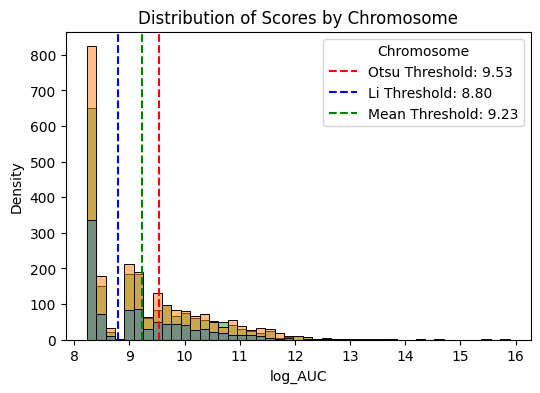

In [4]:
# for each chr plot the distribution of Score
plt.figure(figsize=(6, 4))
sns.histplot(data=k27, x="log_AUC", hue="Chromosome")
plt.axvline(threshold_df.loc[0, "otsu_threshold"], color="red", linestyle="--", label=f"Otsu Threshold: {threshold_df.loc[0, "otsu_threshold"]:.2f}")
plt.axvline(threshold_df.loc[0, "li_threshold"], color="blue", linestyle="--", label=f"Li Threshold: {threshold_df.loc[0, "li_threshold"]:.2f}")
plt.axvline(threshold_df.loc[0, "mean_threshold"], color="green", linestyle="--", label=f"Mean Threshold: {threshold_df.loc[0, "mean_threshold"]:.2f}")
plt.title("Distribution of Scores by Chromosome")
plt.xlabel("log_AUC")
plt.ylabel("Density")
plt.legend(title="Chromosome")
plt.show()

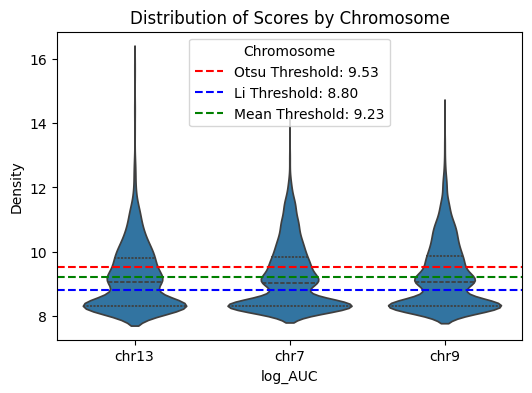

In [5]:
# for each chr plot the distribution of Score
plt.figure(figsize=(6, 4))
sns.violinplot(data=k27, x="Chromosome", y="log_AUC", inner="quartile")
plt.axhline(threshold_df.loc[0, "otsu_threshold"], color="red", linestyle="--", label=f"Otsu Threshold: {threshold_df.loc[0, "otsu_threshold"]:.2f}")
plt.axhline(threshold_df.loc[0, "li_threshold"], color="blue", linestyle="--", label=f"Li Threshold: {threshold_df.loc[0, "li_threshold"]:.2f}")
plt.axhline(threshold_df.loc[0, "mean_threshold"], color="green", linestyle="--", label=f"Mean Threshold: {threshold_df.loc[0, "mean_threshold"]:.2f}")
plt.title("Distribution of Scores by Chromosome")
plt.xlabel("log_AUC")
plt.ylabel("Density")
plt.legend(title="Chromosome")
plt.show()

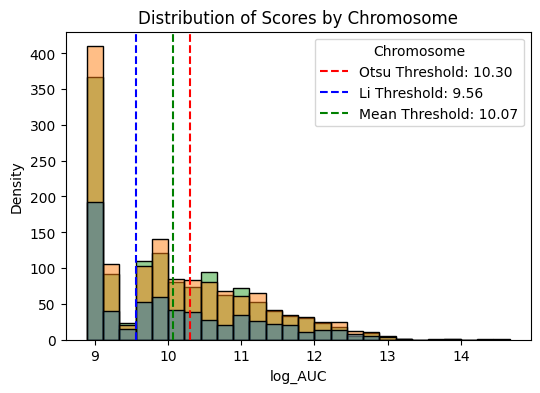

In [6]:
# for each chr plot the distribution of Score
plt.figure(figsize=(6, 4))
sns.histplot(data=mll, x="log_AUC", hue="Chromosome")
plt.axvline(threshold_df.loc[1, "otsu_threshold"], color="red", linestyle="--", label=f"Otsu Threshold: {threshold_df.loc[1, "otsu_threshold"]:.2f}")
plt.axvline(threshold_df.loc[1, "li_threshold"], color="blue", linestyle="--", label=f"Li Threshold: {threshold_df.loc[1, "li_threshold"]:.2f}")
plt.axvline(threshold_df.loc[1, "mean_threshold"], color="green", linestyle="--", label=f"Mean Threshold: {threshold_df.loc[1, "mean_threshold"]:.2f}")
plt.title("Distribution of Scores by Chromosome")
plt.xlabel("log_AUC")
plt.ylabel("Density")
plt.legend(title="Chromosome")
plt.show()

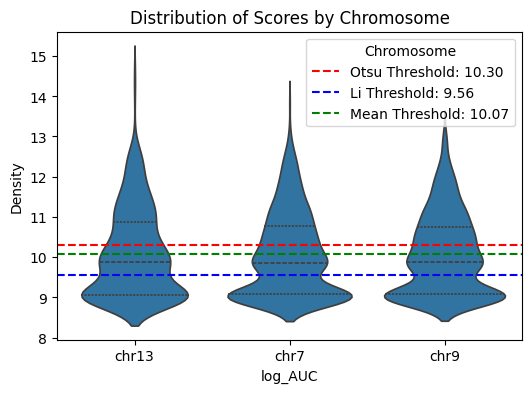

In [7]:
plt.figure(figsize=(6, 4))
sns.violinplot(data=mll, x="Chromosome", y="log_AUC", inner="quartile")
plt.axhline(threshold_df.loc[1, "otsu_threshold"], color="red", linestyle="--", label=f"Otsu Threshold: {threshold_df.loc[1, "otsu_threshold"]:.2f}")
plt.axhline(threshold_df.loc[1, "li_threshold"], color="blue", linestyle="--", label=f"Li Threshold: {threshold_df.loc[1, "li_threshold"]:.2f}")
plt.axhline(threshold_df.loc[1, "mean_threshold"], color="green", linestyle="--", label=f"Mean Threshold: {threshold_df.loc[1, "mean_threshold"]:.2f}")
plt.title("Distribution of Scores by Chromosome")
plt.xlabel("log_AUC")
plt.ylabel("Density")
plt.legend(title="Chromosome")
plt.show()